## Summarize improvement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH_COMPLETE    = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval/metrics_all_experiments.csv"
PATH_MINIMAL     = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_minimal/metrics_all_experiments_minimal.csv"
PATH_SECTORONLY  = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval_sectoronly/metrics_all_experiments_sectoronly.csv"

DATASET_COLORS = {
    "eth_micron": "#2bbfa4",
    "lka_micron": "#f4693d",
    "lka_vam":    "#7b8fd4",
    "moz_vam":    "#f06caa",
    "nga_micron": "#92c63e",
    "nga_mics":   "#f5c100",
    "yem_mvam":   "#c8a86b",
    "zwe_mics":   "#aaaaaa",
}

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
import pandas as pd
import numpy as np

def load_var_exp(path, default_train_percent=1, yemen_train_percent=10):
    cols_needed = [
        "experiment_id", "country", "dataset", "train_percent_int",
        "seed", "adm1_code", "adm1_name", "target",
        "emd_gen", "emd_over",
        "absmeanerr_gen", "absmeanerr_over",
    ]
    raw = pd.read_csv(path, usecols=lambda c: c in cols_needed)

    # use train_percent = 10 for Yemen, 1 for all other countries
    raw = raw[
        ((raw["country"] == "yem") & (raw["train_percent_int"] == yemen_train_percent)) |
        ((raw["country"] != "yem") & (raw["train_percent_int"] == default_train_percent))
    ].copy()

    # step 1: average over seeds → one row per (experiment, adm1, target)
    group_keys = [
        "experiment_id", "country", "dataset", "train_percent_int",
        "adm1_code", "adm1_name", "target"
    ]
    adm1_seedmean = (
        raw.groupby(group_keys, as_index=False)
           .agg(
               emd_gen_mean=("emd_gen", "mean"),
               emd_over_mean=("emd_over", "mean"),
               abs_gen_mean=("absmeanerr_gen", "mean"),
               abs_over_mean=("absmeanerr_over", "mean"),
           )
    )

    # step 2: average over adm1 → one row per (experiment, target)
    keys_var = ["experiment_id", "country", "dataset", "train_percent_int", "target"]
    var_exp = (
        adm1_seedmean.groupby(keys_var, as_index=False)
                     .agg(
                         emd_gen_mean=("emd_gen_mean", "mean"),
                         emd_over_mean=("emd_over_mean", "mean"),
                         abs_gen_mean=("abs_gen_mean", "mean"),
                         abs_over_mean=("abs_over_mean", "mean"),
                     )
    )

    var_exp["emd_improv"] = var_exp["emd_over_mean"] - var_exp["emd_gen_mean"]
    var_exp["ame_improv"] = var_exp["abs_over_mean"] - var_exp["abs_gen_mean"]
    return var_exp

var_exp_complete   = load_var_exp(PATH_COMPLETE,   default_train_percent=1, yemen_train_percent=10)
var_exp_complete["model"] = "complete"

var_exp_minimal    = load_var_exp(PATH_MINIMAL,    default_train_percent=1, yemen_train_percent=10)
var_exp_minimal["model"] = "minimal"

var_exp_sectoronly = load_var_exp(PATH_SECTORONLY, default_train_percent=1, yemen_train_percent=10)
var_exp_sectoronly["model"] = "sectoronly"

print("complete:",   var_exp_complete.shape,   "  minimal:", var_exp_minimal.shape,   "  sectoronly:", var_exp_sectoronly.shape)
print("\ncomplete experiments:",   var_exp_complete["experiment_id"].unique())
print("minimal experiments:  ",   var_exp_minimal["experiment_id"].unique())
print("sectoronly experiments:", var_exp_sectoronly["experiment_id"].unique())

print("\nTrain percents kept in complete:")
print(var_exp_complete[["country", "dataset", "train_percent_int"]].drop_duplicates().sort_values(["country", "dataset"]))

print("\nTrain percents kept in minimal:")
print(var_exp_minimal[["country", "dataset", "train_percent_int"]].drop_duplicates().sort_values(["country", "dataset"]))

print("\nTrain percents kept in sectoronly:")
print(var_exp_sectoronly[["country", "dataset", "train_percent_int"]].drop_duplicates().sort_values(["country", "dataset"]))


complete: (41, 12)   minimal: (41, 12)   sectoronly: (41, 12)

complete experiments: ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'yem_mvam' 'zwe_mics']
minimal experiments:   ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'yem_mvam' 'zwe_mics']
sectoronly experiments: ['eth_micron' 'lka_micron' 'lka_vam' 'moz_vam' 'nga_micron' 'nga_mics'
 'yem_mvam' 'zwe_mics']

Train percents kept in complete:
   country dataset  train_percent_int
0      eth  micron                  1
7      lka  micron                  1
14     lka     vam                  1
20     moz     vam                  1
25     nga  micron                  1
32     nga    mics                  1
35     yem    mvam                 10
38     zwe    mics                  1

Train percents kept in minimal:
   country dataset  train_percent_int
0      eth  micron                  1
7      lka  micron                  1
14     lka     vam                  1
20     moz     vam    

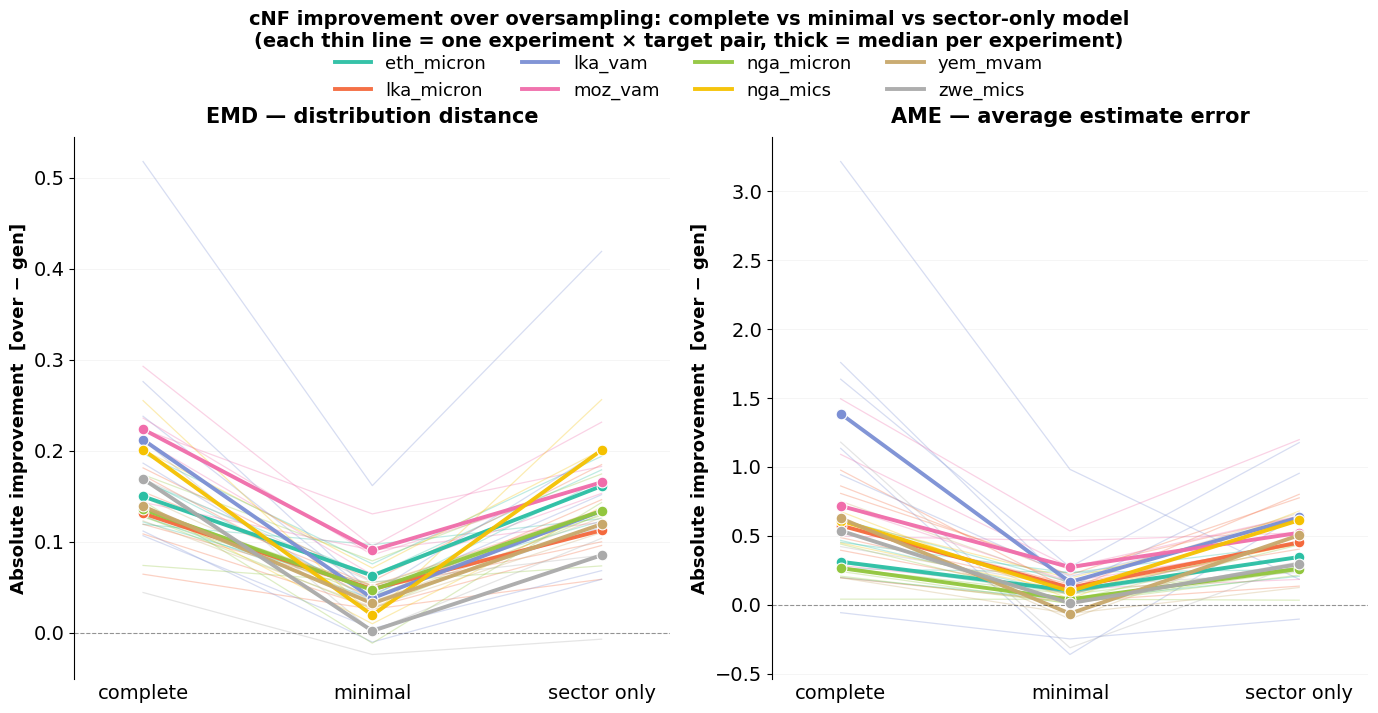

In [3]:
def slope_panel(ax, metric_col, ylabel, title):
    # merge complete, minimal and sectoronly on (experiment, target)
    merge_keys = ["experiment_id", "country", "dataset", "target"]
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    exp_ids = sorted(merged["experiment_id"].unique())

    for exp in exp_ids:
        sub = merged[merged["experiment_id"] == exp]
        color = DATASET_COLORS.get(exp, "#999999")

        # one thin line per (experiment, target) point
        for _, row in sub.iterrows():
            ax.plot(
                [0, 1, 2],
                [row[f"{metric_col}_complete"], row[f"{metric_col}_minimal"], row[f"{metric_col}_sectoronly"]],
                color=color, linewidth=0.9, alpha=0.3, zorder=1
            )

        # thick median line per experiment
        med_c = sub[f"{metric_col}_complete"].median()
        med_m = sub[f"{metric_col}_minimal"].median()
        med_s = sub[f"{metric_col}_sectoronly"].median()
        ax.plot(
            [0, 1, 2], [med_c, med_m, med_s],
            color=color, linewidth=2.8, alpha=0.95, zorder=2, label=exp
        )
        ax.scatter(
            [0, 1, 2], [med_c, med_m, med_s],
            color=color, s=60, zorder=3, edgecolors="white", linewidths=0.8
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["complete", "minimal", "sector only"], fontsize=14)
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=15, fontweight="bold", pad=10)
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis="x", length=0)

    return ax.get_legend_handles_labels()


fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.10, wspace=0.35)

handles, labels = slope_panel(
    axes[0],
    metric_col="emd_improv",
    ylabel="Absolute improvement  [over − gen]",
    title="EMD — distribution distance",
)
slope_panel(
    axes[1],
    metric_col="ame_improv",
    ylabel="Absolute improvement  [over − gen]",
    title="AME — average estimate error",
)

fig.legend(
    handles, labels,
    loc="upper center", bbox_to_anchor=(0.5, 0.98),
    ncol=4, frameon=False, fontsize=13,
)
fig.suptitle(
    "cNF improvement over oversampling: complete vs minimal vs sector-only model\n"
    "(each thin line = one experiment × target pair, thick = median per experiment)",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()


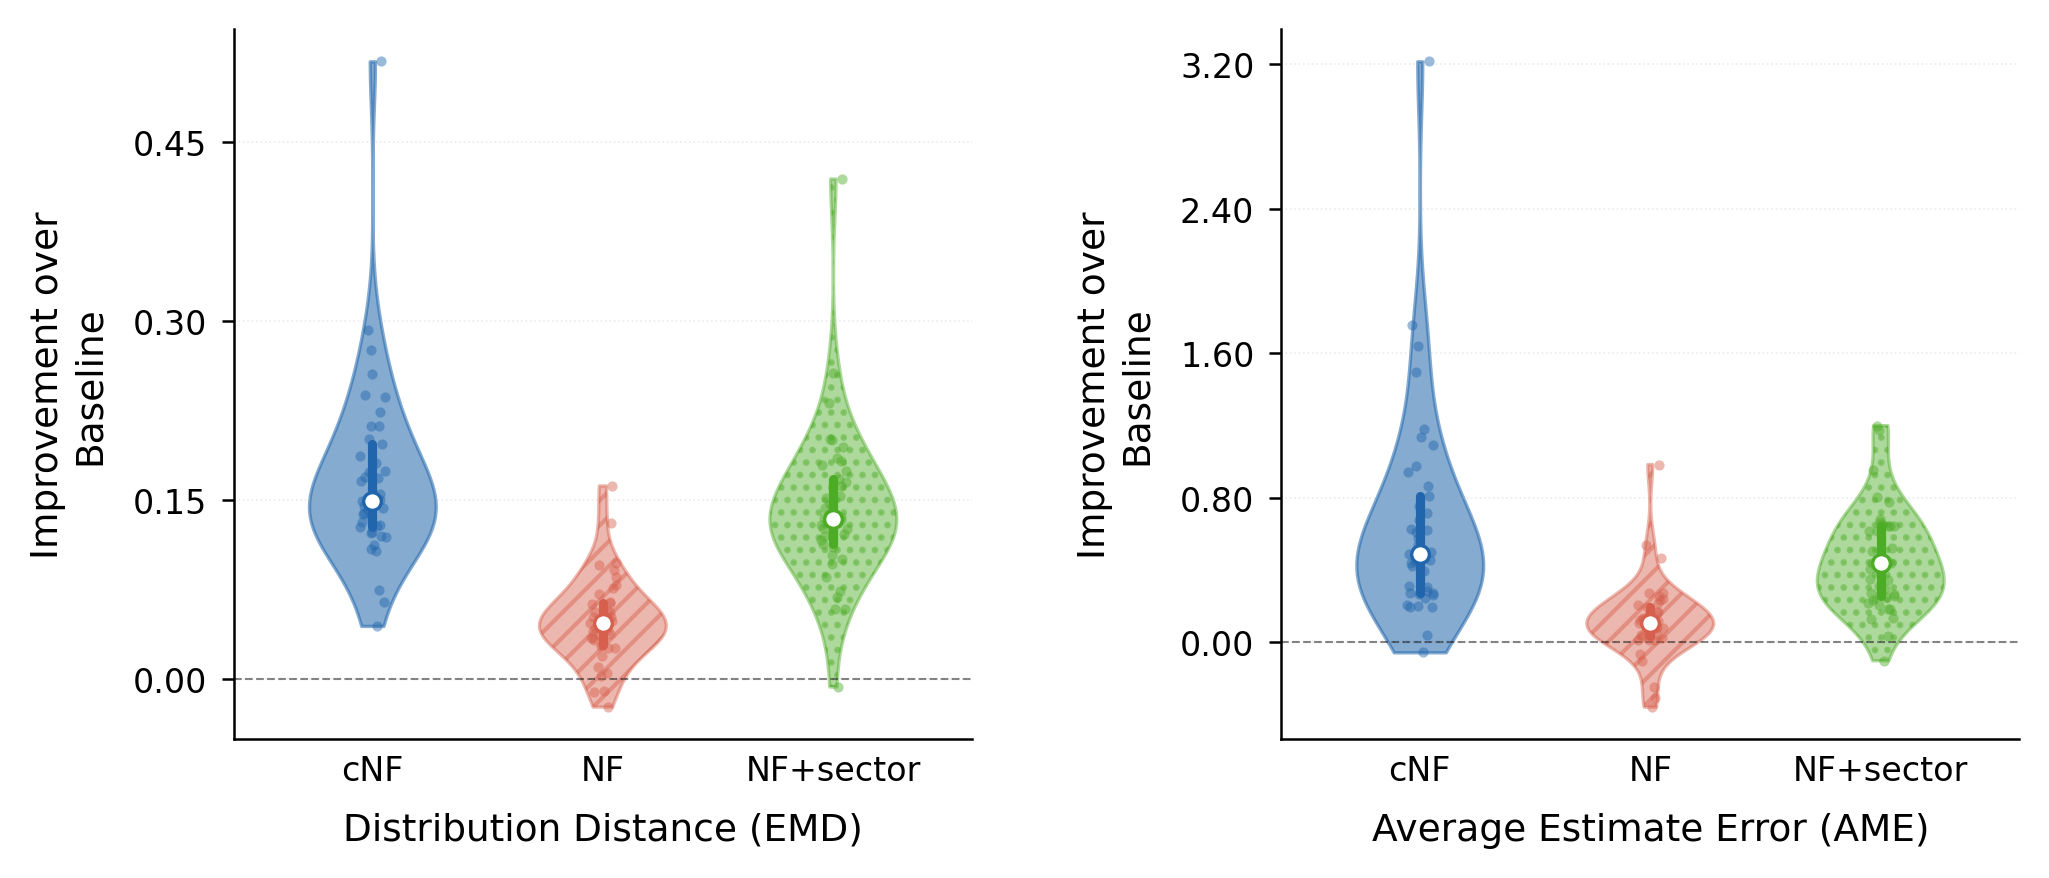

Saved.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

# ── Science Advances style rcParams ─────────────────────────────────────────
plt.rcParams.update({
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
})

C_COMPLETE   = "#2166ac"
C_MINIMAL    = "#d6604d"
C_SECTORONLY = "#4dac26"

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    models  = ["complete", "minimal", "sectoronly"]
    xs      = [0.0, 1.0, 2.0]
    colors  = [C_COMPLETE, C_MINIMAL, C_SECTORONLY]
    alphas  = [0.55, 0.45, 0.45]
    hatches = [None, "////", "...."]

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals, positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # draw IQR box + median manually for cleaner look
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2, solid_capstyle="round", zorder=4)
        ax.scatter(x, med, color="white", s=18, zorder=5, linewidths=0.8,
                   edgecolors=color)

        # individual points as a strip, jittered
        rng = np.random.default_rng(42)
        jitter = rng.uniform(-0.06, 0.06, size=len(vals))
        ax.scatter(x + jitter, vals, color=color, s=6, alpha=0.45,
                   linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF", "NF+sector"], fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9, labelpad=6)
    ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=6)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 2.6)
    ax.tick_params(axis="x", length=0)


# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(3.5 * 2, 3.2),
)
fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.18, wspace=0.42)

make_violin_panel(axes[0], "emd_improv", "Distribution Distance (EMD)")
make_violin_panel(axes[1], "ame_improv", "Average Estimate Error (AME)")

fig.savefig("violin_improvement.pdf", bbox_inches="tight", dpi=300)
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved.")


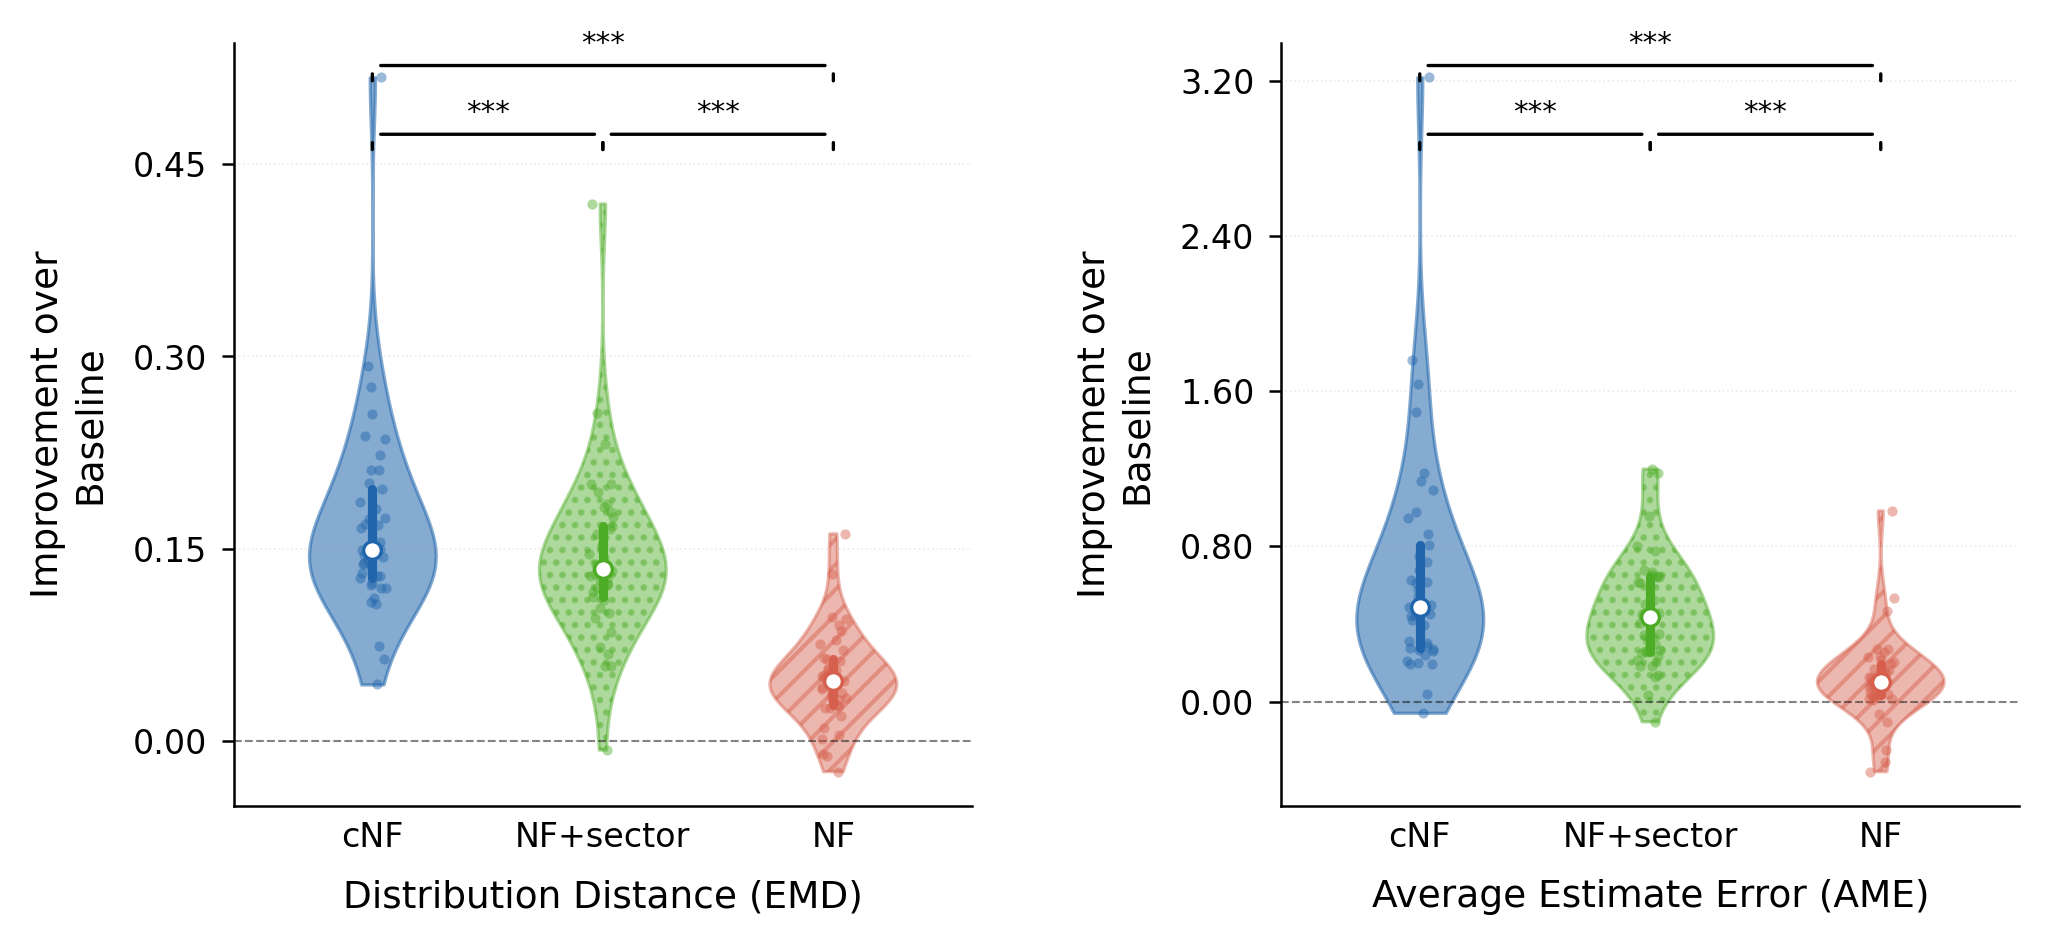

Saved.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
from scipy.stats import wilcoxon

# ── Science Advances style rcParams ─────────────────────────────────────────
plt.rcParams.update({
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
})

C_COMPLETE   = "#2166ac"
C_SECTORONLY = "#4dac26"
C_MINIMAL    = "#d6604d"

merge_keys = ["experiment_id", "country", "dataset", "target"]


def significance_label(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def draw_significance_bracket(ax, x1, x2, y, label, color="black"):
    """Draw a bracket between x1 and x2 at height y with a significance label."""
    h = 0.012  # tick height in data coords (will be overridden by ax transform below)
    ax.annotate(
        "", xy=(x2, y), xytext=(x1, y),
        xycoords=("data", "axes fraction"),
        textcoords=("data", "axes fraction"),
        arrowprops=dict(arrowstyle="-", color=color, lw=0.8),
    )
    # vertical ticks at each end
    for xpos in [x1, x2]:
        ax.annotate(
            "", xy=(xpos, y - 0.02), xytext=(xpos, y),
            xycoords=("data", "axes fraction"),
            textcoords=("data", "axes fraction"),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.8),
        )
    ax.text(
        (x1 + x2) / 2, y + 0.01,
        label,
        transform=ax.get_xaxis_transform(),
        ha="center", va="bottom",
        fontsize=7, color=color,
    )


def make_violin_panel(ax, metric_col, xlabel):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    # order: cNF, NF+sector, NF
    models  = ["complete", "sectoronly", "minimal"]
    xs      = [0.0, 1.0, 2.0]
    colors  = [C_COMPLETE, C_SECTORONLY, C_MINIMAL]
    alphas  = [0.55, 0.45, 0.45]
    hatches = [None, "....", "////"]
    labels  = ["cNF", "NF+sector", "NF"]

    rng = np.random.default_rng(42)

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals, positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # draw IQR box + median manually for cleaner look
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=4)
        ax.scatter(x, med, color="white", s=18, zorder=5, linewidths=0.8,
                   edgecolors=color)

        # individual points as a strip, jittered
        jitter = rng.uniform(-0.06, 0.06, size=len(vals))
        ax.scatter(x + jitter, vals, color=color, s=6, alpha=0.45,
                   linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel(xlabel, fontsize=9, labelpad=6)
    ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=6)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 2.6)
    ax.tick_params(axis="x", length=0)

    # ── Paired one-sided Wilcoxon tests (left > right) ───────────────────
    # pairs in display order: (cNF, NF+sector), (NF+sector, NF), (cNF, NF)
    pairs = [
        ("complete",   "sectoronly", 0.0, 1.0, 0.88),
        ("sectoronly", "minimal",    1.0, 2.0, 0.88),
        ("complete",   "minimal",    0.0, 2.0, 0.97),
    ]

    for left_model, right_model, x1, x2, y_frac in pairs:
        a = merged[f"{metric_col}_{left_model}"].values
        b = merged[f"{metric_col}_{right_model}"].values
        diff = a - b
        # one-sided: testing left > right, i.e. diff > 0
        if np.all(diff == 0):
            p = 1.0
        else:
            _, p = wilcoxon(diff, alternative="greater")
        label = significance_label(p)
        draw_significance_bracket(ax, x1, x2, y_frac, label)


# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2, figsize=(3.5 * 2, 3.8),   # slightly taller to accommodate brackets
)
fig.subplots_adjust(left=0.12, right=0.97, top=0.85, bottom=0.18, wspace=0.42)

make_violin_panel(axes[0], "emd_improv", "Distribution Distance (EMD)")
make_violin_panel(axes[1], "ame_improv", "Average Estimate Error (AME)")

fig.savefig("violin_improvement.pdf", bbox_inches="tight", dpi=300)
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved.")

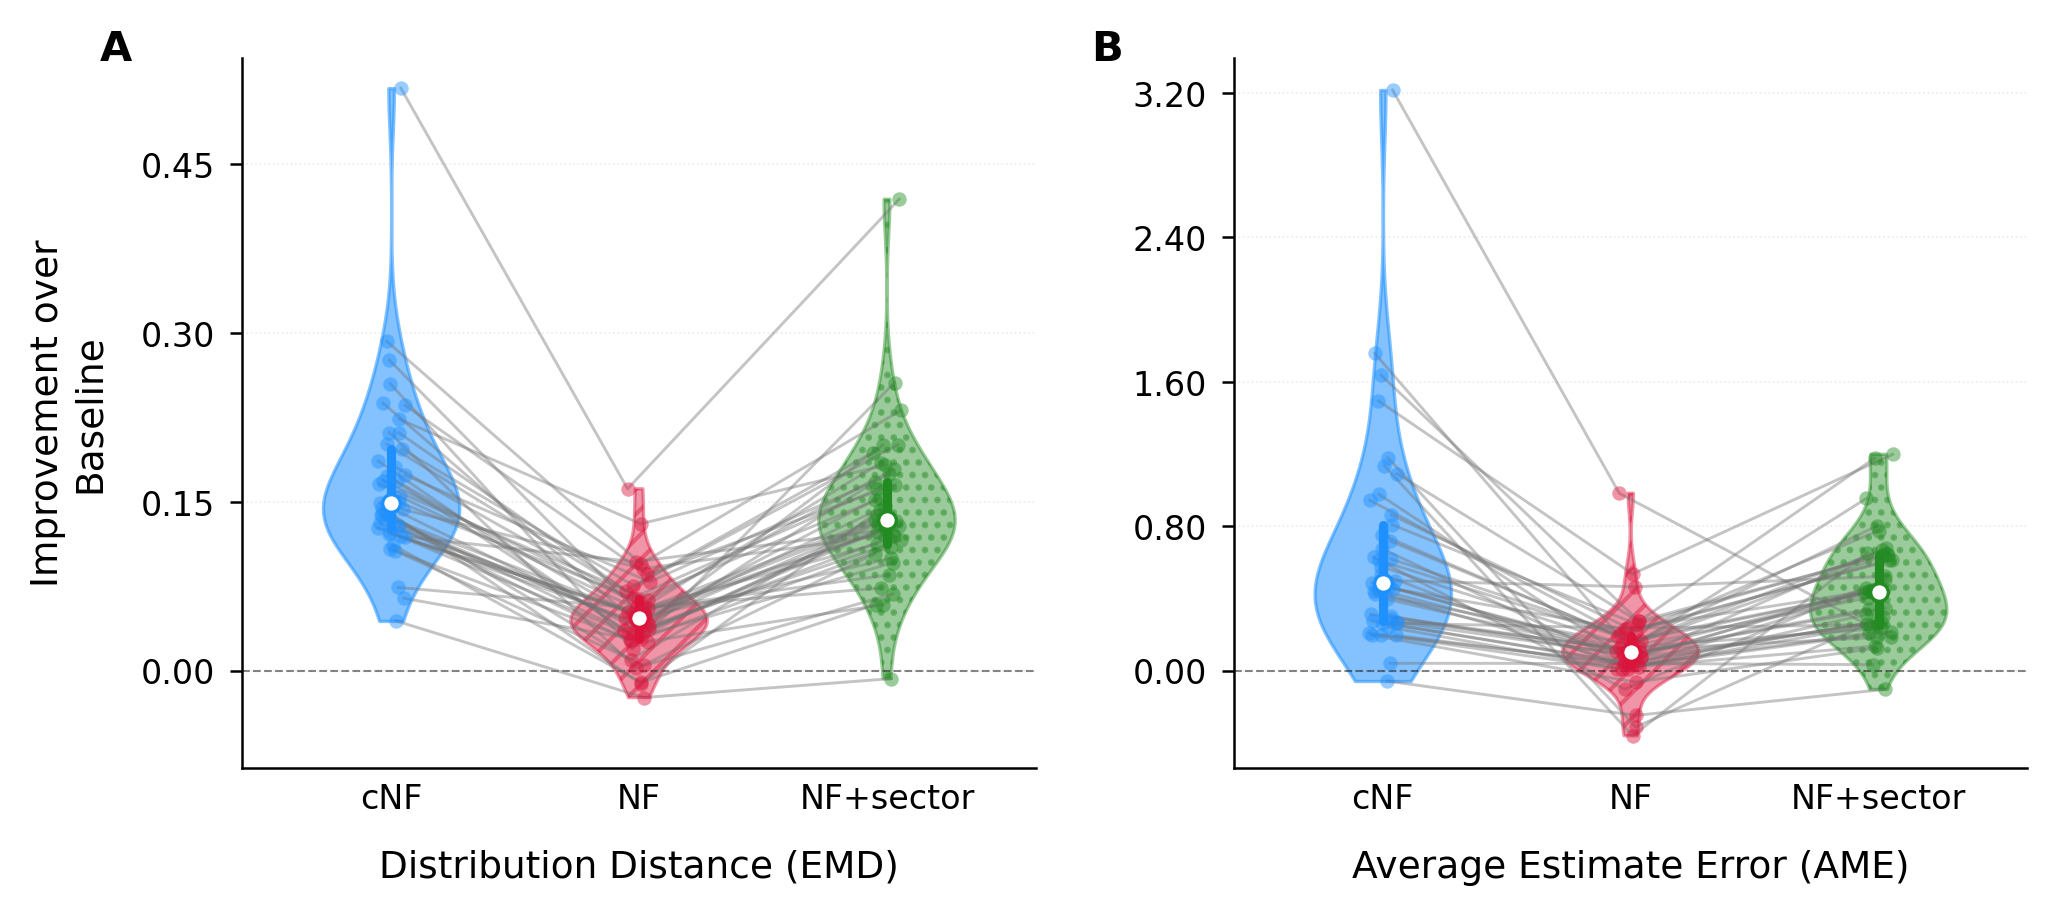

Saved as violin_improvement.svg and violin_improvement.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Helvetica / Science-style rcParams ─────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         300,
    "svg.fonttype":       "none",   # keep text editable in SVG
})

C_COMPLETE   = 'DodgerBlue'
C_MINIMAL    = 'Crimson'
C_SECTORONLY = 'ForestGreen'

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel, panel_label, show_ylabel=False):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    x_complete   = 0.0
    x_minimal    = 1.0
    x_sectoronly = 2.0

    models  = ["complete", "minimal", "sectoronly"]
    xs      = [x_complete, x_minimal, x_sectoronly]
    colors  = [C_COMPLETE, C_MINIMAL, C_SECTORONLY]
    alphas  = [0.55, 0.45, 0.45]
    hatches = [None, "////", "...."]

    rng = np.random.default_rng(42)

    # violins
    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values

        parts = ax.violinplot(
            vals,
            positions=[x],
            widths=0.55,
            showmedians=False,
            showextrema=False,
        )

        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        # IQR + median
        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    # paired lines + points
    vals_complete   = merged[f"{metric_col}_complete"].values
    vals_minimal    = merged[f"{metric_col}_minimal"].values
    vals_sectoronly = merged[f"{metric_col}_sectoronly"].values

    jitter_complete   = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal    = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_sectoronly = rng.uniform(-0.06, 0.06, size=len(merged))

    x1 = x_complete   + jitter_complete
    x2 = x_minimal    + jitter_minimal
    x3 = x_sectoronly + jitter_sectoronly

    for i in range(len(merged)):
        ax.plot(
            [x1[i], x2[i], x3[i]],
            [vals_complete[i], vals_minimal[i], vals_sectoronly[i]],
            color="0.45",
            linewidth=0.7,
            alpha=0.42,
            zorder=2
        )

    ax.scatter(x1, vals_complete,   color=C_COMPLETE,   s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x2, vals_minimal,    color=C_MINIMAL,    s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x3, vals_sectoronly, color=C_SECTORONLY, s=12, alpha=0.45, linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF", "NF+sector"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=8)

    if show_ylabel:
        ax.set_ylabel("Improvement over\nBaseline", fontsize=9, labelpad=8)
    else:
        ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 2.6)
    ax.tick_params(axis="x", length=0)

    # panel letter
    ax.text(
        -0.18, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        va="top",
        ha="left"
    )

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))
fig.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.18, wspace=0.25)

make_violin_panel(
    axes[0],
    metric_col="emd_improv",
    xlabel="Distribution Distance (EMD)",
    panel_label="A",
    show_ylabel=True
)

make_violin_panel(
    axes[1],
    metric_col="ame_improv",
    xlabel="Average Estimate Error (AME)",
    panel_label="B",
    show_ylabel=False
)

# current limits
ymin_left, ymax_left = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()

target_frac = (0 - ymin_right) / (ymax_right - ymin_right)
new_ymin_left  = -target_frac * ymax_left / (1 - target_frac)
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)

axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

fig.savefig("violin_improvement.svg", bbox_inches="tight")
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=300)
plt.show()

print("Saved as violin_improvement.svg and violin_improvement.png")


In [7]:
import os
import pandas as pd
import numpy as np

def make_cnf_percent_table(var_exp, eps=1e-12):
    df = var_exp.copy()

    df["emd_improv_pct"] = np.where(
        df["emd_over_mean"].abs() > eps,
        100 * (df["emd_over_mean"] - df["emd_gen_mean"]) / df["emd_over_mean"],
        np.nan
    )

    df["ame_improv_pct"] = np.where(
        df["abs_over_mean"].abs() > eps,
        100 * (df["abs_over_mean"] - df["abs_gen_mean"]) / df["abs_over_mean"],
        np.nan
    )

    summary = (
        df.groupby(["country", "dataset", "target"], as_index=False)
          .agg(
              emd_over_mean=("emd_over_mean", "mean"),
              emd_gen_mean=("emd_gen_mean", "mean"),
              emd_improv_mean=("emd_improv", "mean"),
              emd_improv_pct_mean=("emd_improv_pct", "mean"),
              ame_over_mean=("abs_over_mean", "mean"),
              ame_gen_mean=("abs_gen_mean", "mean"),
              ame_improv_mean=("ame_improv", "mean"),
              ame_improv_pct_mean=("ame_improv_pct", "mean"),
              n_experiments=("experiment_id", "nunique")
          )
          .sort_values(["country", "dataset", "target"])
    )

    return summary

out_dir = "/data/shared/fsibilla/clean_code/Q1/across_experiments_eval"
os.makedirs(out_dir, exist_ok=True)

for var_exp, label, fname in [
    (var_exp_complete,   "complete",   "cnf_percent_improvement_by_dataset_variable.txt"),
    (var_exp_minimal,    "minimal",    "cnf_percent_improvement_by_dataset_variable_minimal.txt"),
    (var_exp_sectoronly, "sectoronly", "cnf_percent_improvement_by_dataset_variable_sectoronly.txt"),
]:
    tbl = make_cnf_percent_table(var_exp)
    out_txt = os.path.join(out_dir, fname)
    with open(out_txt, "w") as f:
        f.write(tbl.round(2).to_string(index=False))
    print(f"Saved {label} to: {out_txt}")


Saved complete to: /data/shared/fsibilla/clean_code/Q1/across_experiments_eval/cnf_percent_improvement_by_dataset_variable.txt
Saved minimal to: /data/shared/fsibilla/clean_code/Q1/across_experiments_eval/cnf_percent_improvement_by_dataset_variable_minimal.txt
Saved sectoronly to: /data/shared/fsibilla/clean_code/Q1/across_experiments_eval/cnf_percent_improvement_by_dataset_variable_sectoronly.txt


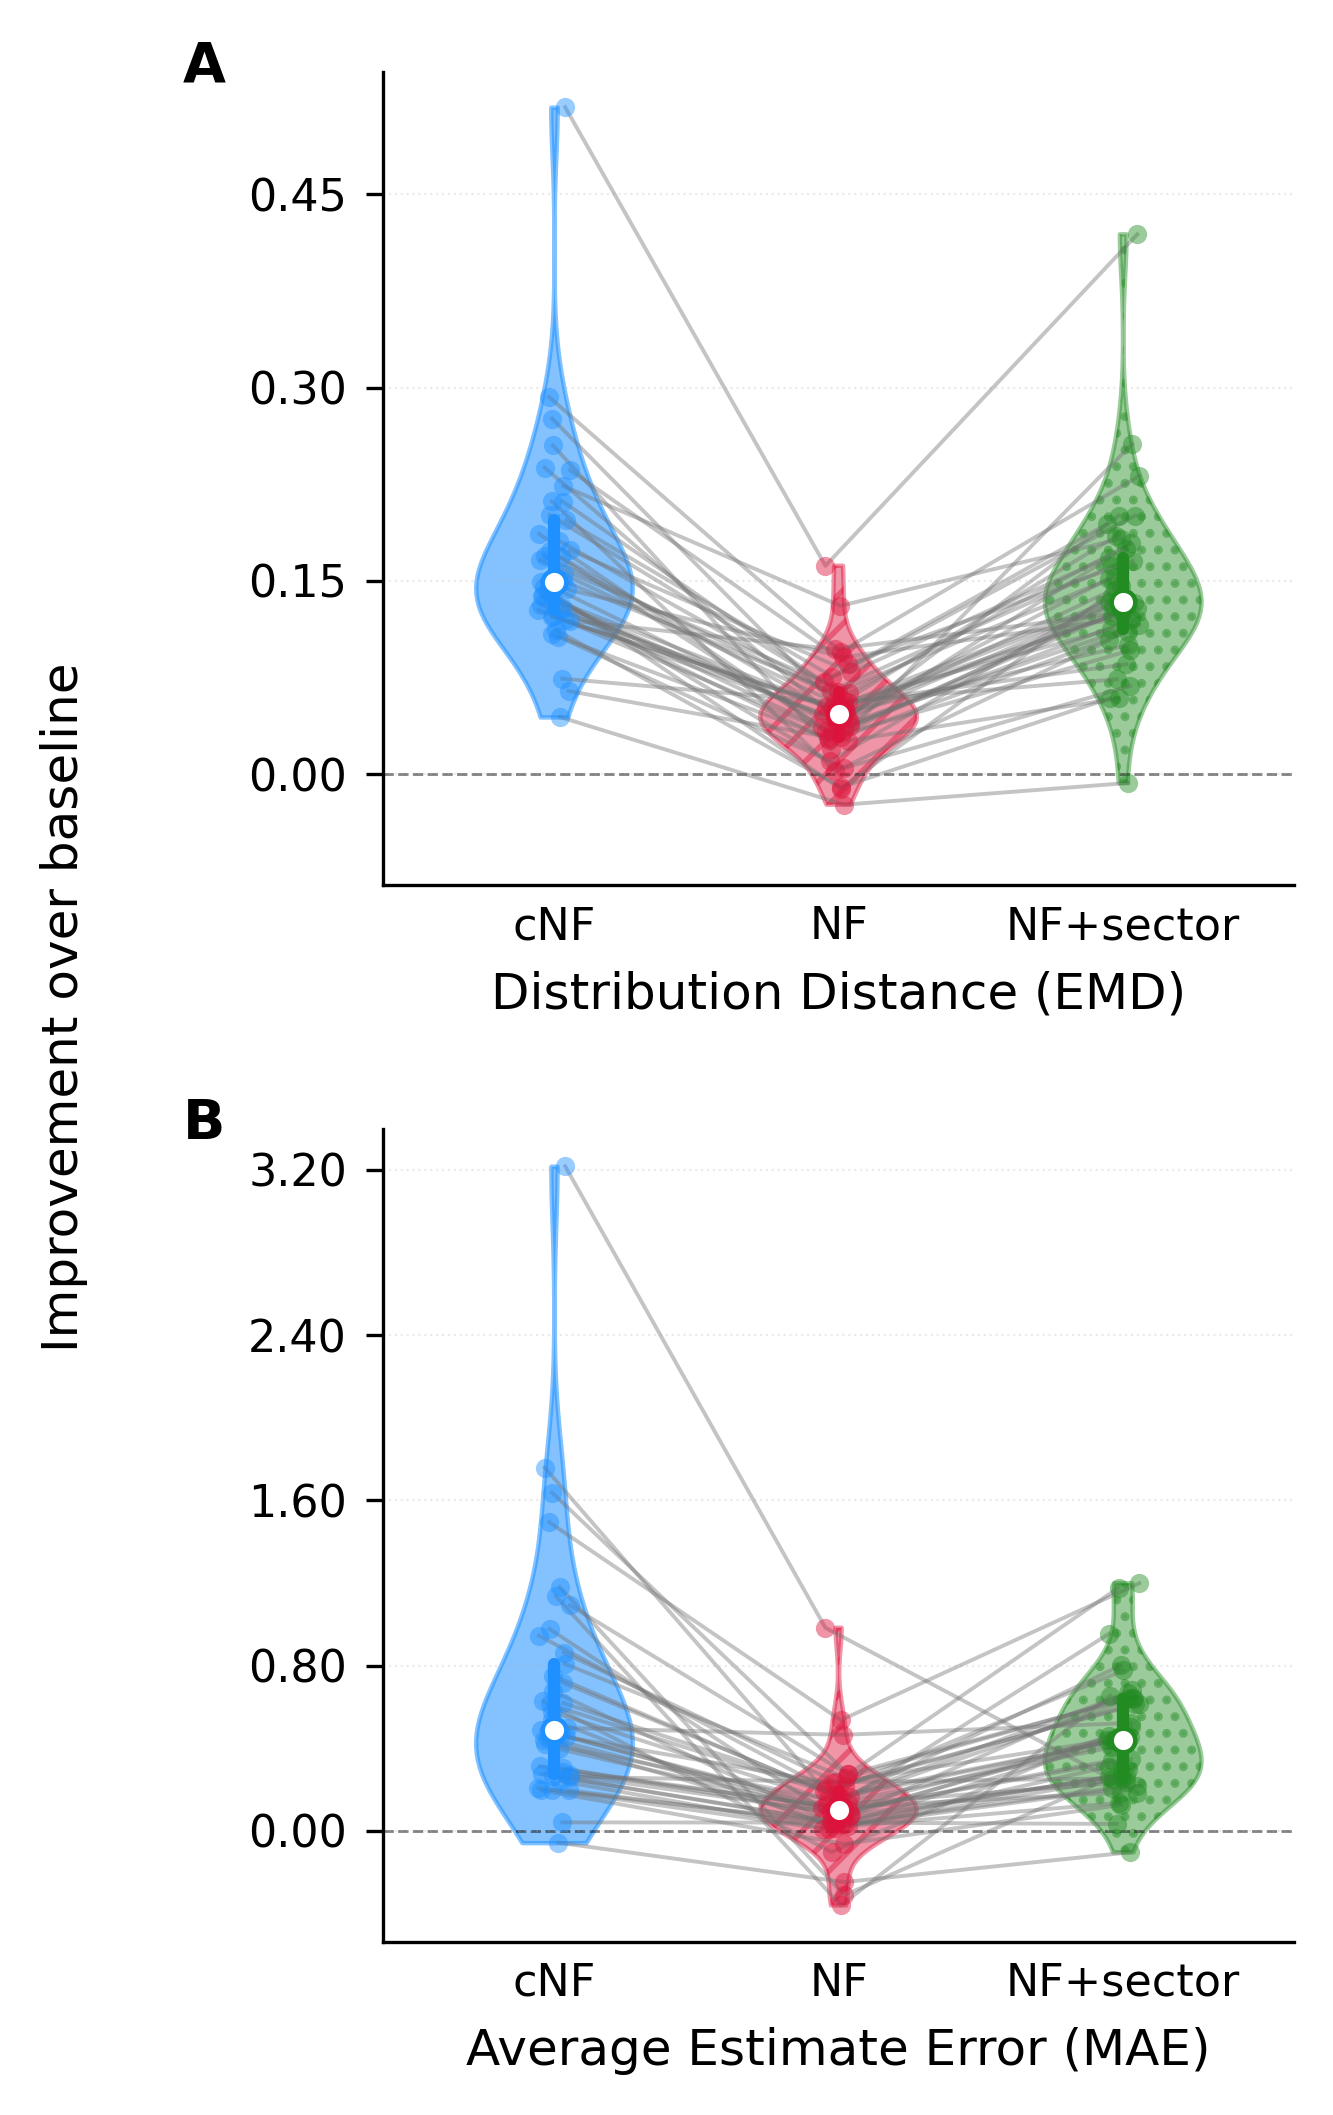

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_COMPLETE   = 'DodgerBlue'
C_MINIMAL    = 'Crimson'
C_SECTORONLY = 'ForestGreen'

merge_keys = ["experiment_id", "country", "dataset", "target"]

def make_violin_panel(ax, metric_col, xlabel, panel_label):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    x_complete   = 0.0
    x_minimal    = 1.0
    x_sectoronly = 2.0
    models  = ["complete", "minimal", "sectoronly"]
    xs      = [x_complete, x_minimal, x_sectoronly]
    colors  = [C_COMPLETE, C_MINIMAL, C_SECTORONLY]
    alphas  = [0.55, 0.45, 0.45]
    hatches = [None, "////", "...."]

    rng = np.random.default_rng(42)

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values
        parts = ax.violinplot(
            vals, positions=[x], widths=0.55,
            showmedians=False, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    vals_complete   = merged[f"{metric_col}_complete"].values
    vals_minimal    = merged[f"{metric_col}_minimal"].values
    vals_sectoronly = merged[f"{metric_col}_sectoronly"].values

    jitter_complete   = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal    = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_sectoronly = rng.uniform(-0.06, 0.06, size=len(merged))

    x1 = x_complete   + jitter_complete
    x2 = x_minimal    + jitter_minimal
    x3 = x_sectoronly + jitter_sectoronly

    for i in range(len(merged)):
        ax.plot([x1[i], x2[i], x3[i]],
                [vals_complete[i], vals_minimal[i], vals_sectoronly[i]],
                color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

    ax.scatter(x1, vals_complete,   color=C_COMPLETE,   s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x2, vals_minimal,    color=C_MINIMAL,    s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x3, vals_sectoronly, color=C_SECTORONLY, s=12, alpha=0.45, linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF", "NF+sector"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=4)
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 2.6)
    ax.tick_params(axis="x", length=0)

    ax.text(
        -0.22, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10, fontweight="bold",
        va="top", ha="left"
    )

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(3.3, 5.5))
fig.subplots_adjust(left=0.28, right=0.97, top=0.95, bottom=0.10, hspace=0.30)

make_violin_panel(axes[0], metric_col="emd_improv",
                  xlabel="Distribution Distance (EMD)", panel_label="A")
make_violin_panel(axes[1], metric_col="ame_improv",
                  xlabel="Average Estimate Error (MAE)", panel_label="B")

# ── Shared y label centered between both panels ───────────────────────────
y_center = (0.10 + 0.95) / 2
fig.text(
    0.02, y_center,
    "Improvement over baseline",
    fontsize=9, fontweight="normal",
    ha="left", va="center", rotation=90,
)

# ── Align zero across both panels ────────────────────────────────────────
ymin_left,  ymax_left  = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()
target_frac    = (0 - ymin_right) / (ymax_right - ymin_right)
new_ymin_left  = -target_frac * ymax_left / (1 - target_frac)
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

# ── Save ─────────────────────────────────────────────────────────────────
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_improvement.pdf", bbox_inches="tight")
fig.savefig("violin_improvement.svg", bbox_inches="tight")
plt.show()


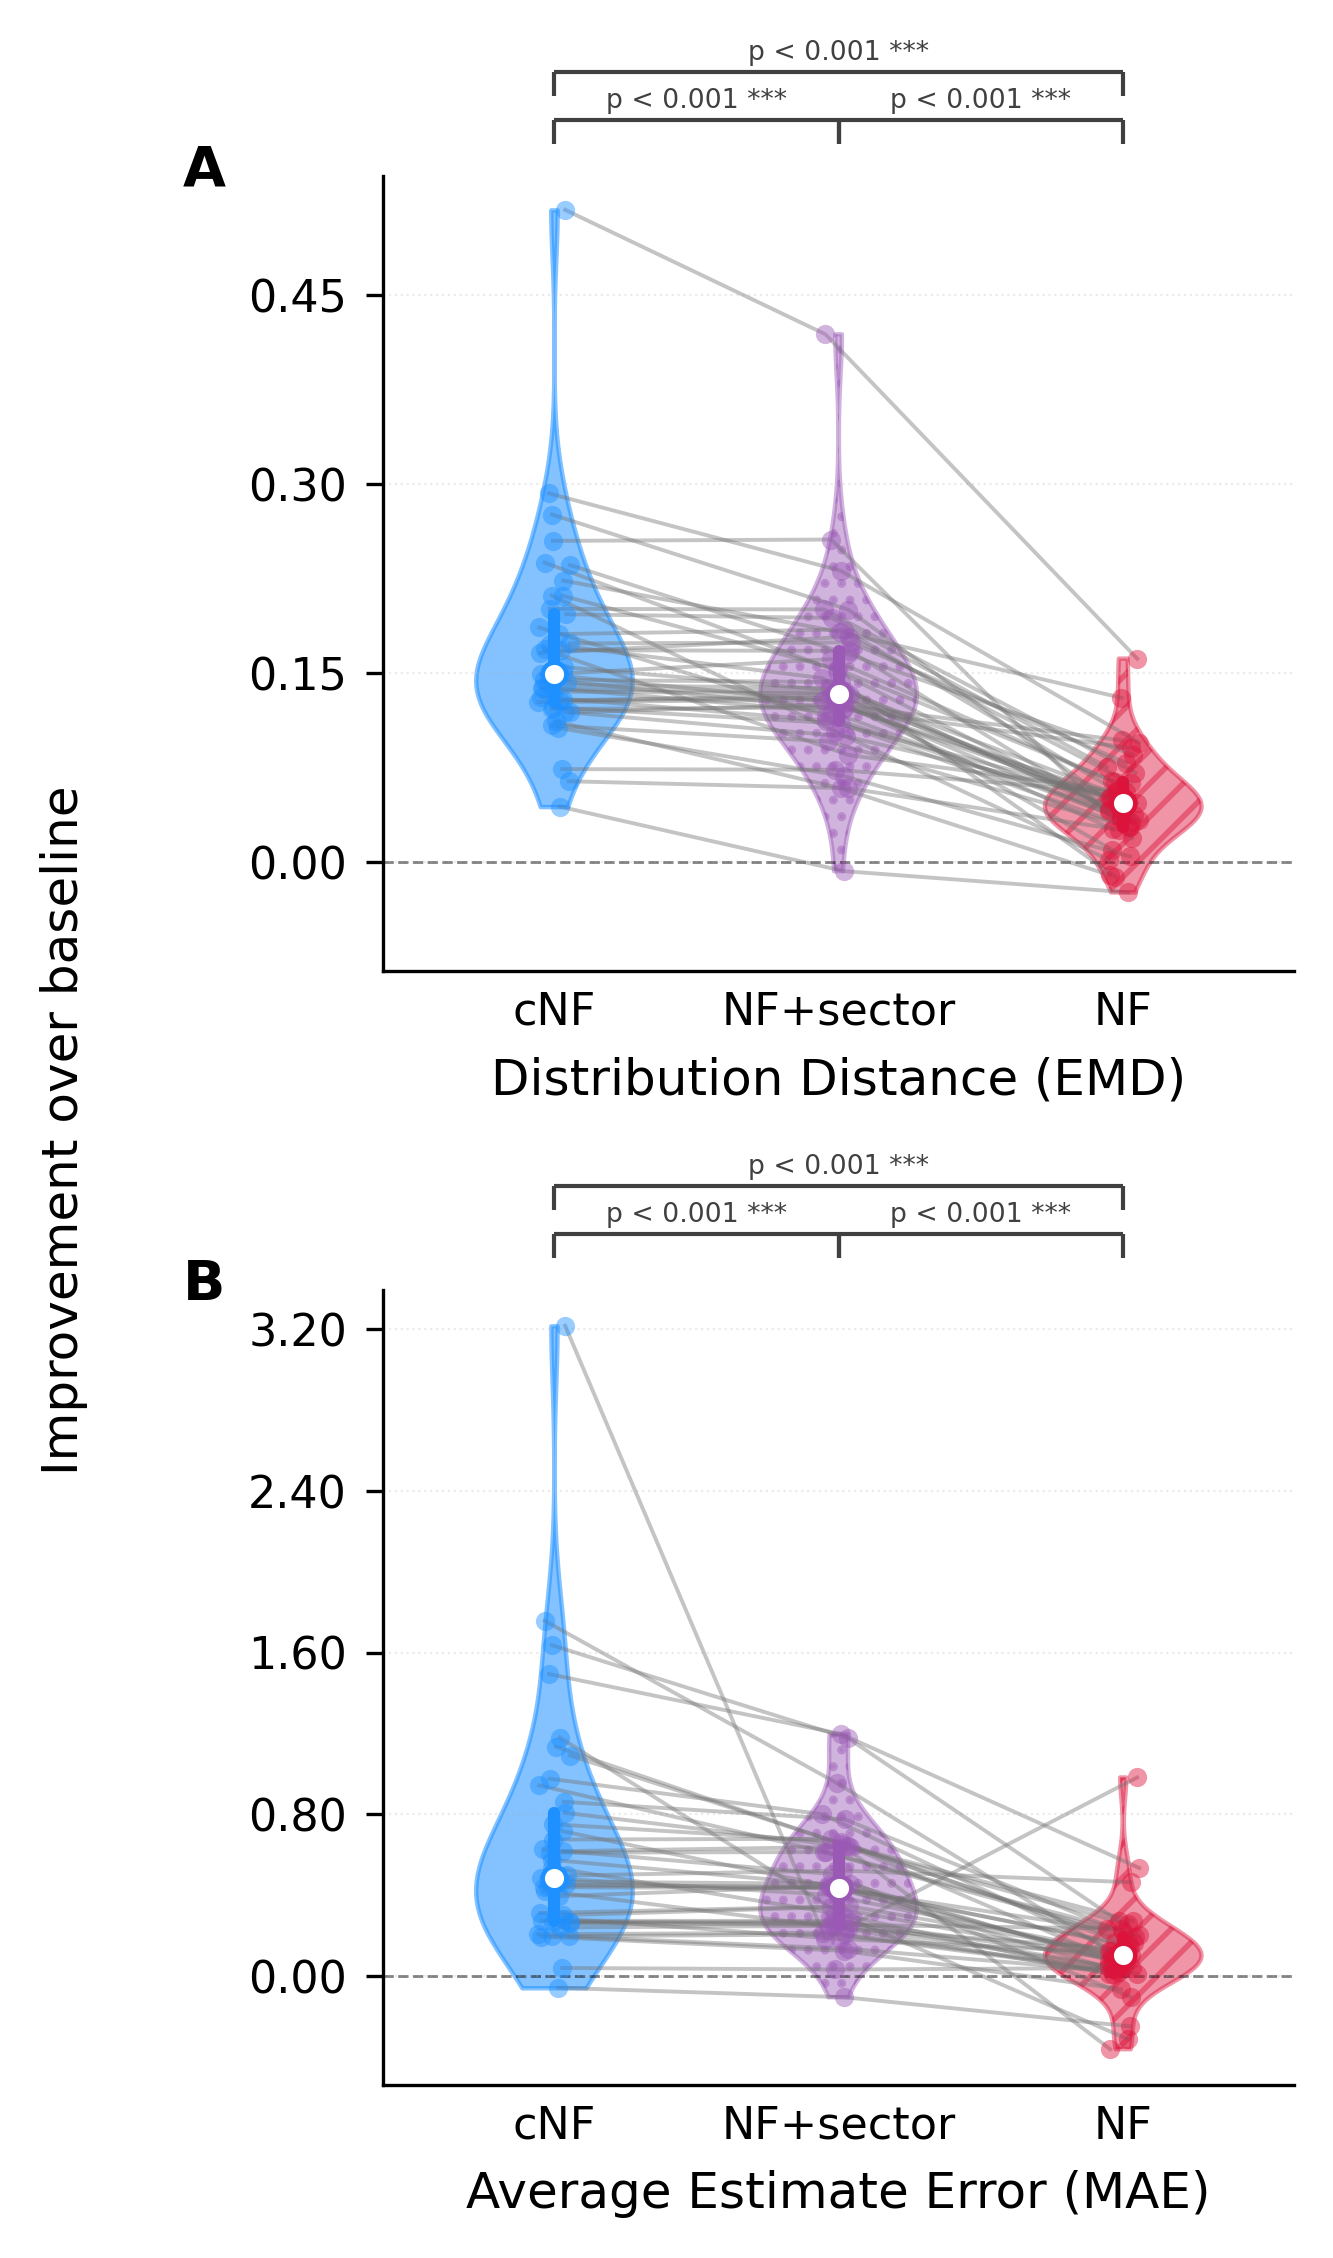

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.stats import wilcoxon

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     9,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_COMPLETE   = 'DodgerBlue'
C_SECTORONLY = '#9b59b6'
C_MINIMAL    = 'Crimson'

merge_keys = ["experiment_id", "country", "dataset", "target"]


def significance_label(p):
    if p < 0.001:
        return "p < 0.001 ***"
    elif p < 0.01:
        return f"p = {p:.3f} **"
    elif p < 0.05:
        return f"p = {p:.3f} *"
    else:
        return f"p = {p:.2f}"


def draw_bracket(ax, x1, x2, y_frac, label, tick_h=0.03):
    """
    Draw a square significance bracket using ax.plot in mixed
    (data-x, axes-fraction-y) coordinates via get_xaxis_transform().
    """
    trans = ax.get_xaxis_transform()
    color = "0.25"
    lw    = 0.75

    # horizontal bar
    ax.plot([x1, x2], [y_frac, y_frac],
            transform=trans, color=color, lw=lw,
            clip_on=False, solid_capstyle="butt")
    # left descender
    ax.plot([x1, x1], [y_frac - tick_h, y_frac],
            transform=trans, color=color, lw=lw,
            clip_on=False, solid_capstyle="butt")
    # right descender
    ax.plot([x2, x2], [y_frac - tick_h, y_frac],
            transform=trans, color=color, lw=lw,
            clip_on=False, solid_capstyle="butt")
    # label centred just above the bar
    ax.text(
        (x1 + x2) / 2, y_frac + 0.008,
        label,
        transform=trans,
        ha="center", va="bottom",
        fontsize=4.8, color=color,
        clip_on=False,
    )


def make_violin_panel(ax, metric_col, xlabel, panel_label):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    # order: cNF, NF+sector, NF
    x_complete   = 0.0
    x_sectoronly = 1.0
    x_minimal    = 2.0
    models  = ["complete", "sectoronly", "minimal"]
    xs      = [x_complete, x_sectoronly, x_minimal]
    colors  = [C_COMPLETE, C_SECTORONLY, C_MINIMAL]
    alphas  = [0.55, 0.45, 0.45]
    hatches = [None, "....", "////"]

    rng = np.random.default_rng(42)

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values
        parts = ax.violinplot(
            vals, positions=[x], widths=0.55,
            showmedians=False, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    vals_complete   = merged[f"{metric_col}_complete"].values
    vals_sectoronly = merged[f"{metric_col}_sectoronly"].values
    vals_minimal    = merged[f"{metric_col}_minimal"].values

    jitter_complete   = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_sectoronly = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal    = rng.uniform(-0.06, 0.06, size=len(merged))

    x1 = x_complete   + jitter_complete
    x2 = x_sectoronly + jitter_sectoronly
    x3 = x_minimal    + jitter_minimal

    for i in range(len(merged)):
        ax.plot([x1[i], x2[i], x3[i]],
                [vals_complete[i], vals_sectoronly[i], vals_minimal[i]],
                color="0.45", linewidth=0.7, alpha=0.42, zorder=2)

    ax.scatter(x1, vals_complete,   color=C_COMPLETE,   s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x2, vals_sectoronly, color=C_SECTORONLY, s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x3, vals_minimal,    color=C_MINIMAL,    s=12, alpha=0.45, linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF+sector", "NF"])
    ax.set_xlabel(xlabel, fontsize=9, labelpad=4)
    ax.set_ylabel("")

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 2.6)
    ax.tick_params(axis="x", length=0)

    ax.text(
        -0.22, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=10, fontweight="bold",
        va="top", ha="left"
    )

    # ── Paired one-sided Wilcoxon (left > right) ─────────────────────────
    # adjacent pair brackets at y=1.07, spanning bracket at y=1.18
    pairs = [
        ("complete",   "sectoronly", x_complete,   x_sectoronly, 1.07),
        ("sectoronly", "minimal",    x_sectoronly, x_minimal,    1.07),
        ("complete",   "minimal",    x_complete,   x_minimal,    1.13),
    ]

    for left_m, right_m, xl, xr, y_frac in pairs:
        a = merged[f"{metric_col}_{left_m}"].values
        b = merged[f"{metric_col}_{right_m}"].values
        diff = a - b
        if np.all(diff == 0):
            p = 1.0
        else:
            _, p = wilcoxon(diff, alternative="greater")
        draw_bracket(ax, xl, xr, y_frac, significance_label(p))


# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(3.3, 6.2))
fig.subplots_adjust(left=0.28, right=0.97, top=0.87, bottom=0.10, hspace=0.40)

make_violin_panel(axes[0], metric_col="emd_improv",
                  xlabel="Distribution Distance (EMD)", panel_label="A")
make_violin_panel(axes[1], metric_col="ame_improv",
                  xlabel="Average Estimate Error (MAE)", panel_label="B")

# ── Shared y label centered between both panels ───────────────────────────
y_center = (0.10 + 0.87) / 2
fig.text(
    0.02, y_center,
    "Improvement over baseline",
    fontsize=9, fontweight="normal",
    ha="left", va="center", rotation=90,
)

# ── Align zero across both panels ────────────────────────────────────────
ymin_left,  ymax_left  = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()
target_frac    = (0 - ymin_right) / (ymax_right - ymin_right)
new_ymin_left  = -target_frac * ymax_left / (1 - target_frac)
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

# ── Save ─────────────────────────────────────────────────────────────────
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_improvement.pdf", bbox_inches="tight")
fig.savefig("violin_improvement.svg", bbox_inches="tight")
plt.show()

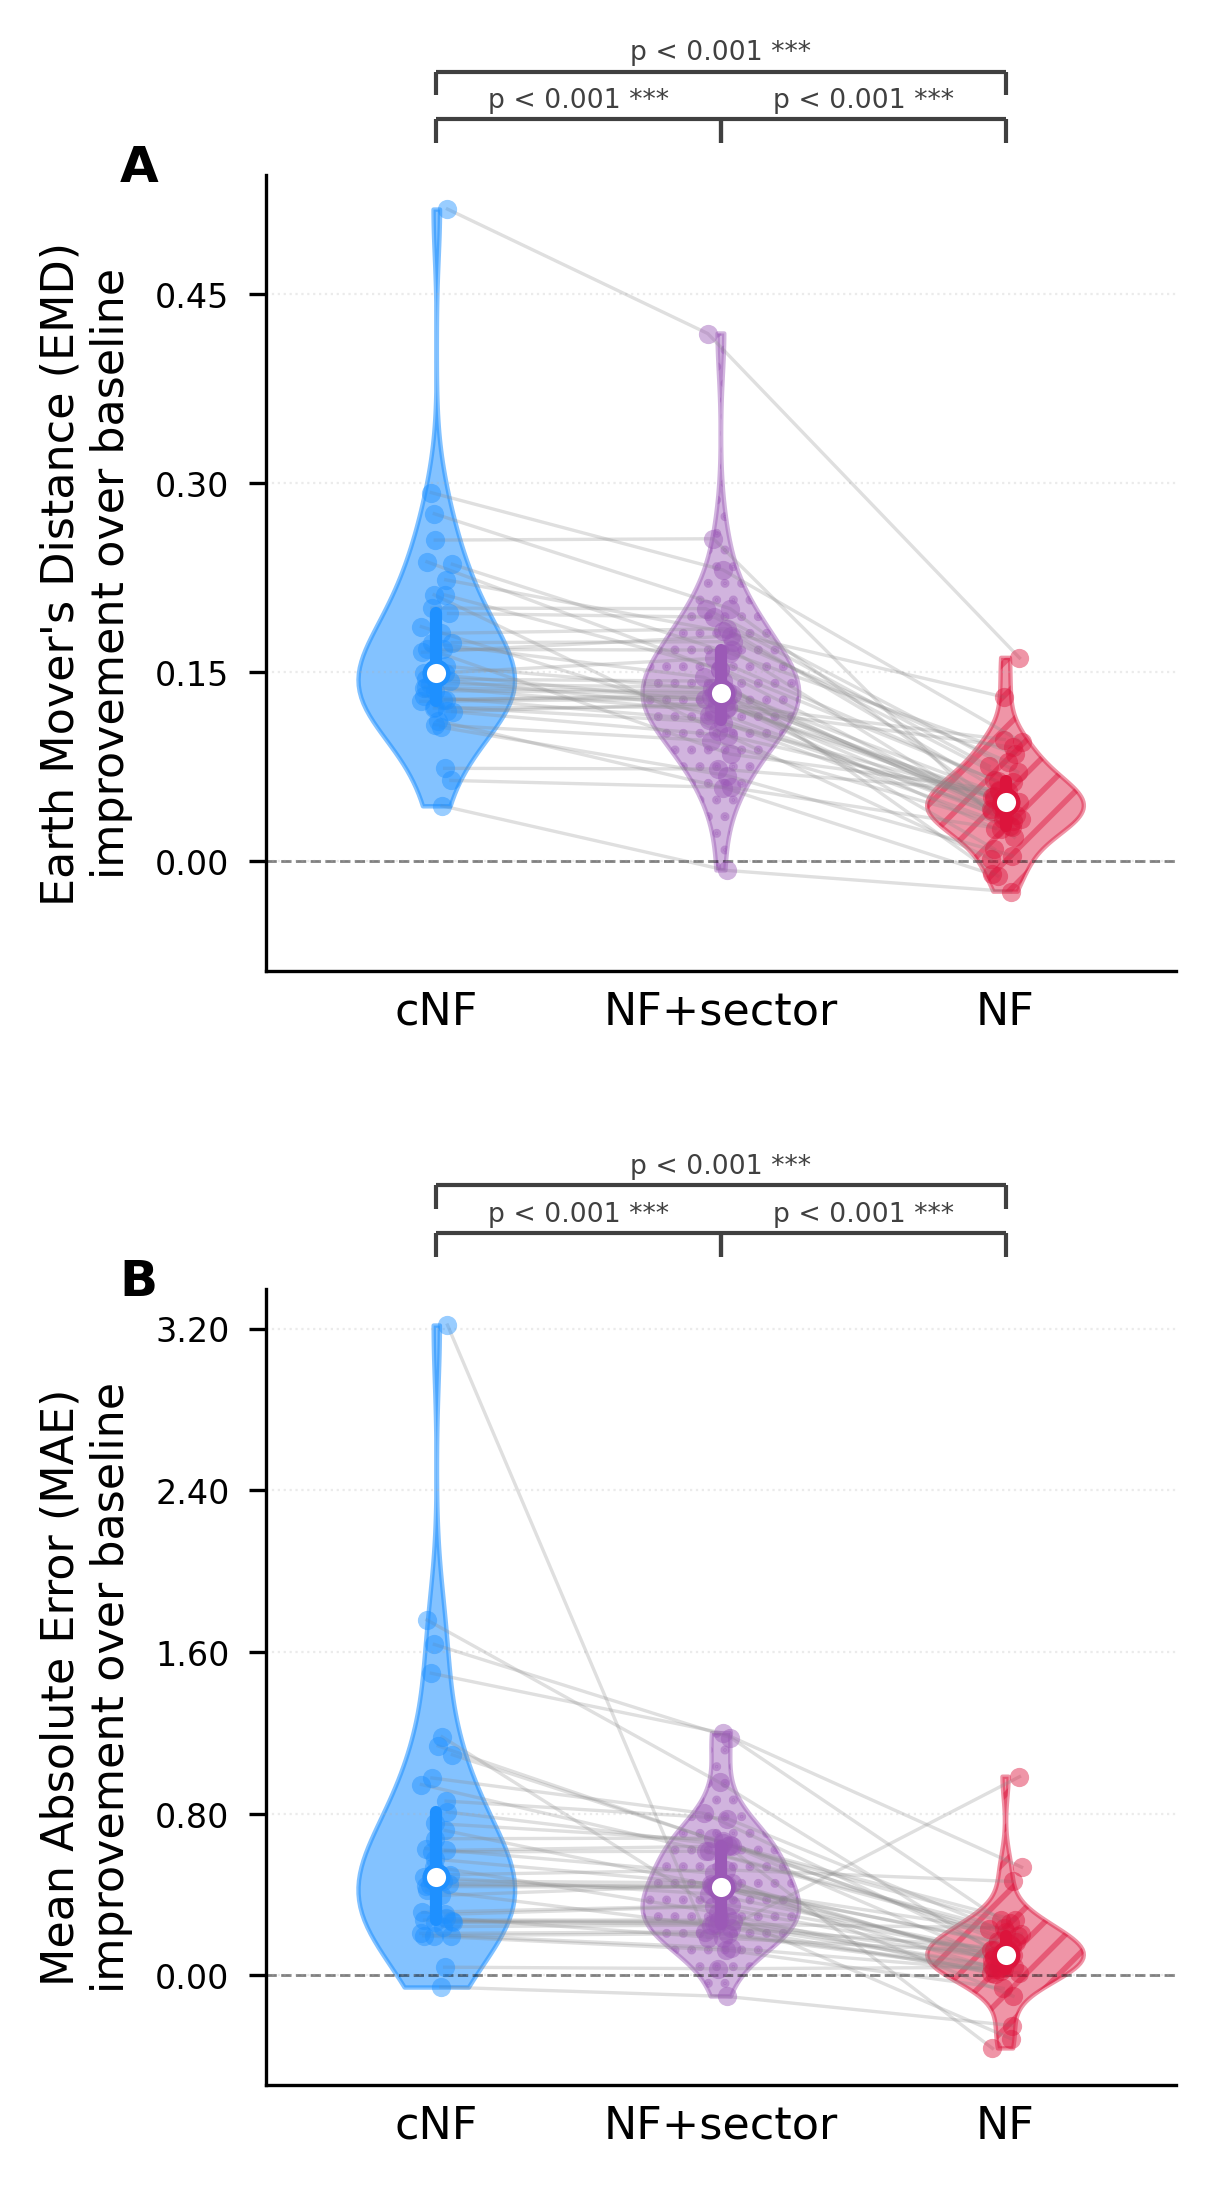

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.stats import wilcoxon

# ── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":          8,
    "axes.labelsize":     8,
    "axes.labelweight":   "normal",
    "axes.titlesize":     9,
    "xtick.labelsize":    8,
    "ytick.labelsize":    6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "axes.linewidth":     0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "figure.dpi":         400,
    "svg.fonttype":       "none",
})

C_COMPLETE   = 'DodgerBlue'
C_SECTORONLY = '#9b59b6'
C_MINIMAL    = 'Crimson'

merge_keys = ["experiment_id", "country", "dataset", "target"]


def significance_label(p):
    if p < 0.001:
        return "p < 0.001 ***"
    elif p < 0.01:
        return f"p = {p:.3f} **"
    elif p < 0.05:
        return f"p = {p:.3f} *"
    else:
        return f"p = {p:.2f}"


def draw_bracket(ax, x1, x2, y_frac, label, tick_h=0.03):
    """
    Draw a square significance bracket using ax.plot in mixed
    (data-x, axes-fraction-y) coordinates via get_xaxis_transform().
    """
    trans = ax.get_xaxis_transform()
    color = "0.25"
    lw    = 0.75

    # horizontal bar
    ax.plot([x1, x2], [y_frac, y_frac],
            transform=trans, color=color, lw=lw,
            clip_on=False, solid_capstyle="butt")
    # left descender
    ax.plot([x1, x1], [y_frac - tick_h, y_frac],
            transform=trans, color=color, lw=lw,
            clip_on=False, solid_capstyle="butt")
    # right descender
    ax.plot([x2, x2], [y_frac - tick_h, y_frac],
            transform=trans, color=color, lw=lw,
            clip_on=False, solid_capstyle="butt")
    # label centred just above the bar
    ax.text(
        (x1 + x2) / 2, y_frac + 0.008,
        label,
        transform=trans,
        ha="center", va="bottom",
        fontsize=4.8, color=color,
        clip_on=False,
    )


def make_violin_panel(ax, metric_col, ylabel, panel_label):
    merged = var_exp_complete[merge_keys + [metric_col]].merge(
        var_exp_minimal[merge_keys + [metric_col]],
        on=merge_keys,
        suffixes=("_complete", "_minimal")
    ).merge(
        var_exp_sectoronly[merge_keys + [metric_col]].rename(
            columns={metric_col: f"{metric_col}_sectoronly"}
        ),
        on=merge_keys,
    ).dropna()

    # order: cNF, NF+sector, NF
    x_complete   = 0.0
    x_sectoronly = 1.0
    x_minimal    = 2.0
    models  = ["complete", "sectoronly", "minimal"]
    xs      = [x_complete, x_sectoronly, x_minimal]
    colors  = [C_COMPLETE, C_SECTORONLY, C_MINIMAL]
    alphas  = [0.55, 0.45, 0.45]
    hatches = [None, "....", "////"]

    rng = np.random.default_rng(42)

    for x, model, color, alpha, hatch in zip(xs, models, colors, alphas, hatches):
        vals = merged[f"{metric_col}_{model}"].values
        parts = ax.violinplot(
            vals, positions=[x], widths=0.55,
            showmedians=False, showextrema=False,
        )
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_edgecolor(color)
            pc.set_alpha(alpha)
            pc.set_linewidth(0.8)
            if hatch:
                pc.set_hatch(hatch)

        q25, med, q75 = np.percentile(vals, [25, 50, 75])
        ax.plot([x, x], [q25, q75], color=color, linewidth=2.2,
                solid_capstyle="round", zorder=5)
        ax.scatter(x, med, color="white", s=18, zorder=6,
                   linewidths=0.8, edgecolors=color)

    vals_complete   = merged[f"{metric_col}_complete"].values
    vals_sectoronly = merged[f"{metric_col}_sectoronly"].values
    vals_minimal    = merged[f"{metric_col}_minimal"].values

    jitter_complete   = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_sectoronly = rng.uniform(-0.06, 0.06, size=len(merged))
    jitter_minimal    = rng.uniform(-0.06, 0.06, size=len(merged))

    x1 = x_complete   + jitter_complete
    x2 = x_sectoronly + jitter_sectoronly
    x3 = x_minimal    + jitter_minimal

    for i in range(len(merged)):
        ax.plot([x1[i], x2[i], x3[i]],
                [vals_complete[i], vals_sectoronly[i], vals_minimal[i]],
                color="0.55", linewidth=0.6, alpha=0.28, zorder=2)

    ax.scatter(x1, vals_complete,   color=C_COMPLETE,   s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x2, vals_sectoronly, color=C_SECTORONLY, s=12, alpha=0.45, linewidths=0, zorder=3)
    ax.scatter(x3, vals_minimal,    color=C_MINIMAL,    s=12, alpha=0.45, linewidths=0, zorder=3)

    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xticks(xs)
    ax.set_xticklabels(["cNF", "NF+sector", "NF"])
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=8)

    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, symmetric=False))
    ax.grid(axis="y", linewidth=0.4, alpha=0.25, linestyle=":")
    ax.set_xlim(-0.6, 2.6)
    ax.tick_params(axis="x", length=0)
    ax.tick_params(axis="y", labelsize=6)

    ax.text(
        -0.16, 1.04, panel_label,
        transform=ax.transAxes,
        fontsize=9, fontweight="bold",
        va="top", ha="left"
    )

    # ── Paired one-sided Wilcoxon (left > right) ─────────────────────────
    # bracket placement kept as in the original
    pairs = [
        ("complete",   "sectoronly", x_complete,   x_sectoronly, 1.07),
        ("sectoronly", "minimal",    x_sectoronly, x_minimal,    1.07),
        ("complete",   "minimal",    x_complete,   x_minimal,    1.13),
    ]

    for left_m, right_m, xl, xr, y_frac in pairs:
        a = merged[f"{metric_col}_{left_m}"].values
        b = merged[f"{metric_col}_{right_m}"].values
        diff = a - b
        if np.all(diff == 0):
            p = 1.0
        else:
            _, p = wilcoxon(diff, alternative="greater")
        draw_bracket(ax, xl, xr, y_frac, significance_label(p))


# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(3.3, 6.2))
fig.subplots_adjust(left=0.28, right=0.97, top=0.87, bottom=0.10, hspace=0.40)

make_violin_panel(
    axes[0],
    metric_col="emd_improv",
    ylabel="Earth Mover's Distance (EMD)\nimprovement over baseline",
    panel_label="A"
)

make_violin_panel(
    axes[1],
    metric_col="ame_improv",
    ylabel="Mean Absolute Error (MAE)\nimprovement over baseline",
    panel_label="B"
)

# ── Align zero across both panels ────────────────────────────────────────
ymin_left,  ymax_left  = axes[0].get_ylim()
ymin_right, ymax_right = axes[1].get_ylim()
target_frac    = (0 - ymin_right) / (ymax_right - ymin_right)
new_ymin_left  = -target_frac * ymax_left / (1 - target_frac)
new_ymax_right = ymin_right * (1 - target_frac) / (-target_frac)
axes[0].set_ylim(new_ymin_left, ymax_left)
axes[1].set_ylim(ymin_right, new_ymax_right)

# ── Save ─────────────────────────────────────────────────────────────────
fig.savefig("violin_improvement.png", bbox_inches="tight", dpi=400)
fig.savefig("violin_improvement.pdf", bbox_inches="tight")
fig.savefig("violin_improvement.svg", bbox_inches="tight")
plt.show()